In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [58]:
import shlex

def _parse_flag(command, flag):
    """Extract the value of --flag from a command string. Returns None if absent."""
    parts = shlex.split(command)
    for i, p in enumerate(parts):
        if p == flag and i + 1 < len(parts):
            return parts[i + 1]
    return None


def load_run(log_path):
    """Parse a single task .out file → (config dict, list of eval dicts).

    Enriches config with 'lr' (from first eval event) and
    'lora_plus_multiplier' (from command string) since these aren't
    present in the config JSON event.
    """
    config, evals = None, []
    for line in Path(log_path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue
        if obj.get("event") == "config":
            config = obj
        elif obj.get("event") == "eval":
            evals.append(obj)
    if config is not None and evals:
        config.setdefault("lr", evals[0]["lr"])
        lp = _parse_flag(config["command"], "--lora_plus_multiplier")
        config.setdefault("lora_plus_multiplier", float(lp) if lp else 1.0)
    return config, evals


def load_sweep(group):
    """Load all runs for a sweep group. Returns list of (config, evals) tuples."""
    log_dir = Path(f"../logs/{group}/run_info/logs")
    runs = []
    for f in sorted(log_dir.glob("*.out")):
        config, evals = load_run(f)
        if config is not None and evals:
            runs.append((config, evals))
    return runs

## LoRA+ (η, m) co-sweep — AdamW, r=16, 1 epoch

In [59]:
lp_runs = load_sweep("loraplus_2k_1ep")
print(f"Loaded {len(lp_runs)} runs")
for cfg, evs in sorted(lp_runs, key=lambda x: (x[0]["lr"], x[0].get("lora_plus_multiplier", 1))):
    lr = cfg["lr"]
    m = cfg.get("lora_plus_multiplier", 1.0)
    print(f"  η={lr:.0e}  m={m:.0f}  steps={[e['step'] for e in evs]}")

Loaded 6 runs
  η=1e-04  m=1  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=1e-04  m=4  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=1e-04  m=16  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=3e-04  m=1  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=3e-04  m=4  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=3e-04  m=16  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]


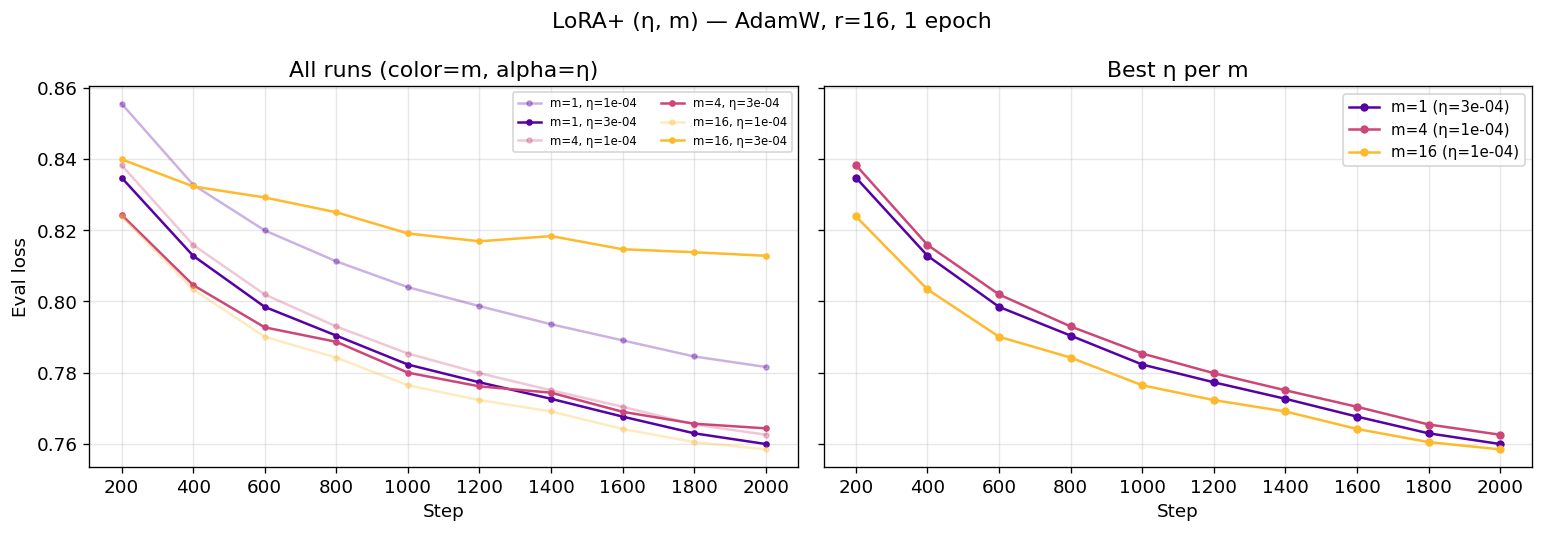

In [60]:
M_COLORS = {1: plt.cm.plasma(0.15), 4: plt.cm.plasma(0.50), 16: plt.cm.plasma(0.85)}

LRS = sorted({cfg["lr"] for cfg, _ in lp_runs})
lr_alphas = {lr: 0.3 + 0.7 * i / max(len(LRS) - 1, 1) for i, lr in enumerate(LRS)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# Left: all runs (color=m, alpha=η)
ax = axes[0]
for cfg, evs in sorted(lp_runs, key=lambda x: (x[0].get("lora_plus_multiplier", 1), x[0]["lr"])):
    lr = cfg["lr"]
    m = int(round(cfg.get("lora_plus_multiplier", 1.0)))
    steps = [e["step"] for e in evs]
    losses = [e["eval_loss"] for e in evs]
    ax.plot(steps, losses,
            color=M_COLORS.get(m, "grey"),
            alpha=lr_alphas[lr],
            marker="o", markersize=3,
            label=f"m={m}, η={lr:.0e}")
ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("All runs (color=m, alpha=η)")
ax.legend(ncol=2, fontsize=7, loc="upper right")

# Right: best η per m
ax = axes[1]
best_per_m = {}
for cfg, evs in lp_runs:
    m = int(round(cfg.get("lora_plus_multiplier", 1.0)))
    fl = evs[-1]["eval_loss"]
    if m not in best_per_m or fl < best_per_m[m][2]:
        best_per_m[m] = (cfg, evs, fl)
for m, (cfg, evs, _) in sorted(best_per_m.items()):
    steps = [e["step"] for e in evs]
    losses = [e["eval_loss"] for e in evs]
    ax.plot(steps, losses,
            color=M_COLORS.get(m, "grey"),
            marker="o", markersize=4,
            label=f"m={m} (η={cfg['lr']:.0e})")
ax.set_xlabel("Step")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("Best η per m")
ax.legend(fontsize=9)

fig.suptitle("LoRA+ (η, m) — AdamW, r=16, 1 epoch")
fig.tight_layout()
plt.show()

## Optimizer comparison — η=3e-4, m=1, r=16, 1 epoch

In [61]:
OPTIM_COLORS = {
    "adamw": "#1f77b4",
    "scaled-lora": "#ff7f0e",
    "lin-lora": "#2ca02c",
    "adam-scaled-lora": "#d62728",
    "adam-lin-lora": "#9467bd",
}


def _has_runs(group):
    """True if the group has at least one populated .out file."""
    log_dir = Path(f"../logs/{group}/run_info/logs")
    if not log_dir.exists():
        return False
    return any(f.stat().st_size > 0 for f in log_dir.glob("*.out"))


# Combine lr_sweep_2k (η ∈ {3e-5,1e-4,3e-4,1e-3}, 5 optims) with the high-η
# extension when present. Dedup on (optimizer, lr).
oc_runs = []
seen = set()
for group in ("optim_compare_high_eta_2k", "lr_sweep_2k", "optim_compare_2k_1ep"):
    if not _has_runs(group):
        continue
    for cfg, evs in load_sweep(group):
        key = (cfg["optimizer"], float(cfg["lr"]))
        if key in seen:
            continue
        seen.add(key)
        oc_runs.append((cfg, evs))

oc_label = f"η sweep, 2000 steps ({len(oc_runs)} runs)"
print(f"Loaded {oc_label}")
for cfg, evs in sorted(oc_runs, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    print(f"  {cfg['optimizer']:20s}  η={cfg['lr']:.0e}  steps through {evs[-1]['step']}  "
          f"final={evs[-1]['eval_loss']:.4f}")

Loaded η sweep, 2000 steps (30 runs)
  adam-lin-lora         η=3e-05  steps through 2000  final=0.8426
  adam-lin-lora         η=1e-04  steps through 2000  final=0.8032
  adam-lin-lora         η=3e-04  steps through 2000  final=0.7723
  adam-lin-lora         η=1e-03  steps through 2000  final=0.7564
  adam-lin-lora         η=3e-03  steps through 2000  final=0.8139
  adam-lin-lora         η=1e-02  steps through 2000  final=1.3112
  adam-scaled-lora      η=3e-05  steps through 2000  final=0.8401
  adam-scaled-lora      η=1e-04  steps through 2000  final=0.8002
  adam-scaled-lora      η=3e-04  steps through 2000  final=0.7702
  adam-scaled-lora      η=1e-03  steps through 2000  final=0.7572
  adam-scaled-lora      η=3e-03  steps through 2000  final=0.8235
  adam-scaled-lora      η=1e-02  steps through 2000  final=1.6646
  adamw                 η=3e-05  steps through 2000  final=0.8088
  adamw                 η=1e-04  steps through 2000  final=0.7795
  adamw                 η=3e-04  steps 

  [filtered diverged] adam-scaled-lora     η=1e-02 max=2.269 final=1.665
  [filtered diverged] adamw                η=1e-02 max=9.009 final=6.937


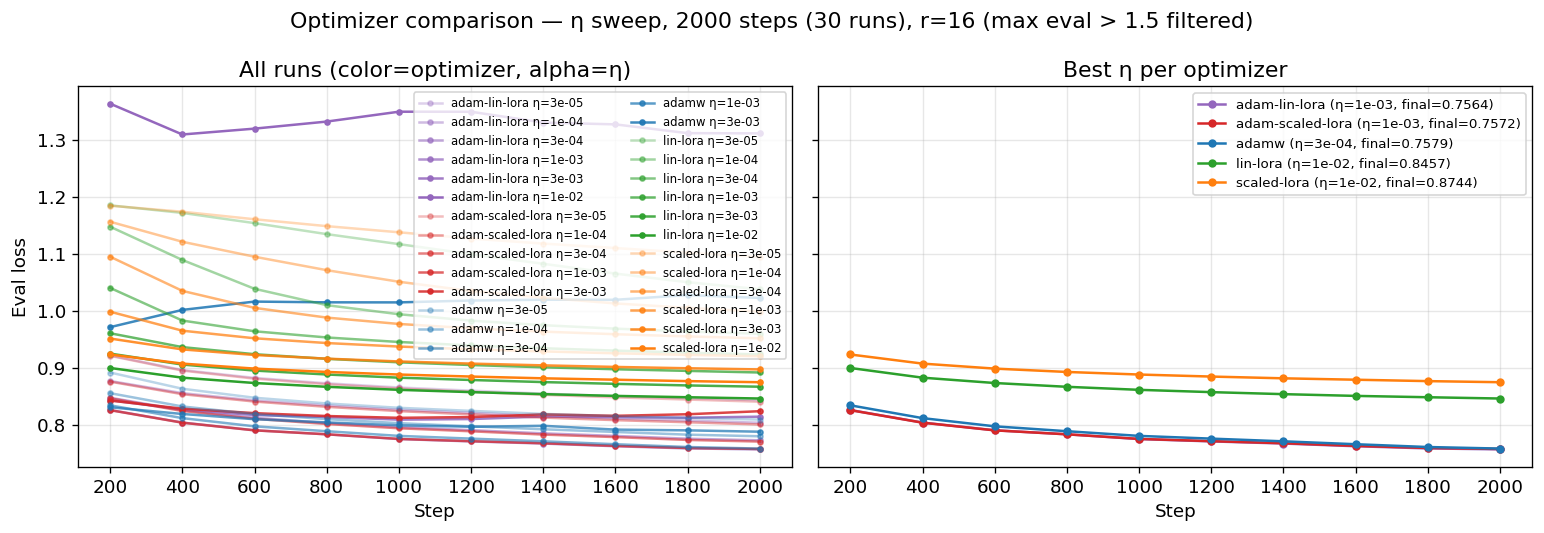

In [62]:
DIVERGE_THRESHOLD_OC = 1.5


def _max_loss(evs):
    return max(e["eval_loss"] for e in evs)


# Filter on max-loss-anywhere — a transient spike still pollutes the y-axis.
oc_keep = [(c, e) for c, e in oc_runs if _max_loss(e) < DIVERGE_THRESHOLD_OC]
oc_drop = [(c, e) for c, e in oc_runs if _max_loss(e) >= DIVERGE_THRESHOLD_OC]
for cfg, evs in sorted(oc_drop, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    print(f"  [filtered diverged] {cfg['optimizer']:20s} η={cfg['lr']:.0e} "
          f"max={_max_loss(evs):.3f} final={evs[-1]['eval_loss']:.3f}")

LRS = sorted({cfg["lr"] for cfg, _ in oc_keep})
lr_alphas = {lr: 0.3 + 0.7 * i / max(len(LRS) - 1, 1) for i, lr in enumerate(LRS)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# Left: all runs (color=optimizer, alpha=η)
ax = axes[0]
for cfg, evs in sorted(oc_keep, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    opt, lr = cfg["optimizer"], cfg["lr"]
    steps = [e["step"] for e in evs]
    losses = [e["eval_loss"] for e in evs]
    ax.plot(steps, losses,
            color=OPTIM_COLORS.get(opt, "grey"),
            alpha=lr_alphas[lr],
            marker="o", markersize=3,
            label=f"{opt} η={lr:.0e}")
ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("All runs (color=optimizer, alpha=η)")
ax.legend(ncol=2, fontsize=7, loc="upper right")

# Right: best η per optimizer
ax = axes[1]
best_per_opt = {}
for cfg, evs in oc_keep:
    opt = cfg["optimizer"]
    fl = evs[-1]["eval_loss"]
    if opt not in best_per_opt or fl < best_per_opt[opt][2]:
        best_per_opt[opt] = (cfg, evs, fl)
for opt, (cfg, evs, fl) in sorted(best_per_opt.items()):
    steps = [e["step"] for e in evs]
    losses = [e["eval_loss"] for e in evs]
    ax.plot(steps, losses,
            color=OPTIM_COLORS.get(opt, "grey"),
            marker="o", markersize=4,
            label=f"{opt} (η={cfg['lr']:.0e}, final={fl:.4f})")
ax.set_xlabel("Step")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("Best η per optimizer")
ax.legend(fontsize=8)

fig.suptitle(f"Optimizer comparison — {oc_label}, r=16 (max eval > {DIVERGE_THRESHOLD_OC} filtered)")
fig.tight_layout()
plt.show()

## SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch

`svd_step_oracle`: each AdamW step projected to rank r via randomized SVD (niter=4).  
`svd_cumulative_oracle`: cumulative displacement from init projected to rank r.  
Both use full dense weights (not LoRA adapters). Reference: best AdamW LoRA at η=3e-4.

In [63]:
svd_runs = load_sweep("svd_sweep_2k_1ep")
print(f"Loaded {len(svd_runs)} SVD oracle runs")
for cfg, evs in sorted(svd_runs, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
    mode = cfg["training_mode"]
    lr = cfg["lr"]
    proj = cfg.get("svd_projection", "?")
    last = evs[-1]["step"]
    el = evs[-1]["eval_loss"]
    print(f"  {mode:<25s}  η={lr:.0e}  {proj}  steps through {last}  eval_loss={el:.4f}")

Loaded 8 SVD oracle runs
  svd_cumulative_oracle      η=3e-05  randomized_niter4  steps through 2000  eval_loss=0.8065
  svd_cumulative_oracle      η=1e-04  randomized_niter4  steps through 2000  eval_loss=0.7869
  svd_cumulative_oracle      η=3e-04  randomized_niter4  steps through 2000  eval_loss=0.9734
  svd_cumulative_oracle      η=1e-03  randomized_niter4  steps through 2000  eval_loss=3.8249
  svd_step_oracle            η=3e-05  randomized_niter4  steps through 2000  eval_loss=0.8773
  svd_step_oracle            η=1e-04  randomized_niter4  steps through 2000  eval_loss=0.8053
  svd_step_oracle            η=3e-04  randomized_niter4  steps through 2000  eval_loss=0.8139
  svd_step_oracle            η=1e-03  randomized_niter4  steps through 2000  eval_loss=2.6889


  [filtered diverged] svd_cumulative_oracle  η=1e-03  max=4.921  final=3.8249
  [filtered diverged] svd_step_oracle  η=1e-03  max=4.947  final=2.6889


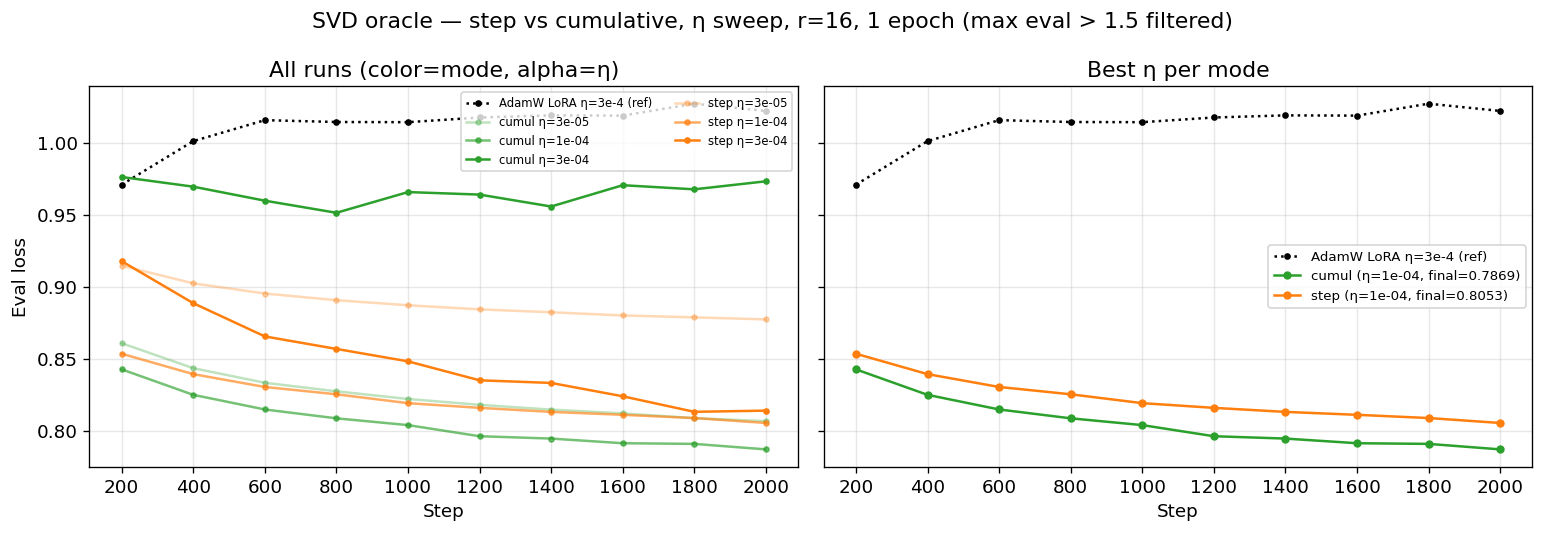

In [64]:
DIVERGE_THRESHOLD = 1.5
MODE_COLORS = {"svd_step_oracle": "#ff7f0e", "svd_cumulative_oracle": "#2ca02c"}


def _max_loss(evs):
    return max(e["eval_loss"] for e in evs)


if not svd_runs:
    print("No SVD oracle results yet — rerun after svd_sweep_2k_1ep completes.")
else:
    converged = [(c, e) for c, e in svd_runs if _max_loss(e) < DIVERGE_THRESHOLD]
    diverged  = [(c, e) for c, e in svd_runs if _max_loss(e) >= DIVERGE_THRESHOLD]
    for cfg, evs in sorted(diverged, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
        print(f"  [filtered diverged] {cfg['training_mode']}  η={cfg['lr']:.0e}  "
              f"max={_max_loss(evs):.3f}  final={evs[-1]['eval_loss']:.4f}")

    LRS = sorted({cfg["lr"] for cfg, _ in converged})
    lr_alphas = {lr: 0.3 + 0.7 * i / max(len(LRS) - 1, 1) for i, lr in enumerate(LRS)}

    adamw_ref = [(cfg, evs) for cfg, evs in oc_runs if cfg["optimizer"] == "adamw"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

    # Left: all runs (color=mode, alpha=η)
    ax = axes[0]
    if adamw_ref:
        cfg_ref, evs_ref = adamw_ref[0]
        ax.plot([e["step"] for e in evs_ref], [e["eval_loss"] for e in evs_ref],
                color="black", lw=1.5, ls=":", marker="o", markersize=3,
                label="AdamW LoRA η=3e-4 (ref)")
    for cfg, evs in sorted(converged, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
        mode, lr = cfg["training_mode"], cfg["lr"]
        steps = [e["step"] for e in evs]
        losses = [e["eval_loss"] for e in evs]
        short = "step" if "step" in mode else "cumul"
        ax.plot(steps, losses,
                color=MODE_COLORS.get(mode, "grey"),
                alpha=lr_alphas[lr],
                marker="o", markersize=3,
                label=f"{short} η={lr:.0e}")
    ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.set_title("All runs (color=mode, alpha=η)")
    ax.legend(ncol=2, fontsize=7, loc="upper right")

    # Right: best η per mode
    ax = axes[1]
    if adamw_ref:
        cfg_ref, evs_ref = adamw_ref[0]
        ax.plot([e["step"] for e in evs_ref], [e["eval_loss"] for e in evs_ref],
                color="black", lw=1.5, ls=":", marker="o", markersize=3,
                label="AdamW LoRA η=3e-4 (ref)")
    best_per_mode = {}
    for cfg, evs in converged:
        mode = cfg["training_mode"]
        fl = evs[-1]["eval_loss"]
        if mode not in best_per_mode or fl < best_per_mode[mode][2]:
            best_per_mode[mode] = (cfg, evs, fl)
    for mode, (cfg, evs, fl) in sorted(best_per_mode.items()):
        steps = [e["step"] for e in evs]
        losses = [e["eval_loss"] for e in evs]
        short = "step" if "step" in mode else "cumul"
        ax.plot(steps, losses,
                color=MODE_COLORS.get(mode, "grey"),
                marker="o", markersize=4,
                label=f"{short} (η={cfg['lr']:.0e}, final={fl:.4f})")
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.set_title("Best η per mode")
    ax.legend(fontsize=8)

    fig.suptitle(f"SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch "
                 f"(max eval > {DIVERGE_THRESHOLD} filtered)")
    fig.tight_layout()
    plt.show()

## New LoRA-mode optimizers — Muon-LoRA, DiagScaledLoRA, KronGradLoRA vs AdamW

η ∈ {3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2}, r=16, seed=0, 2000 steps.
Merged from `muon_lowlr_2k` (post-fix), `new_optimizers_high_eta_2k`,
`new_optimizers_2k`, and `lr_sweep_2k` (AdamW baseline).

**Honest naming.** What we previously called `psi-lora` is *not* PSI-LoRA — it lacks the
LoRSUM proximal subspace iteration, low-rank momentum, and U/V coupling that define the
paper's algorithm. It's just diagonal D_V/D_U scaling on independent factor gradients.
Renamed to **`diag-scaled-lora`**. What we called `kfac-lora` was a custom variant
(r×r gradient outer-product preconditioning on top of diag) with no paper backing.
Renamed to **`kron-grad-lora`**. The `psi-lora` slot is reserved for a faithful
reproduction (forthcoming).

**Muon-LoRA NS bug fix.** Original `_newton_schulz` re-multiplied output by input
Frobenius norm, breaking scale-invariance — combined with PEFT's B=0 init the updates
collapsed and η was nearly irrelevant. Fixed in commit 21cb74b: NS output now has
Frobenius norm √r regardless of input scale (canonical Muon, matches modded-nanogpt).
Tests: `tests/test_new_optimizers.py::test_newton_schulz_*`.

**Final leaderboard at step 2000** (lower is better):

| rank | optimizer        | best η | eval loss |
|------|------------------|--------|-----------|
| 1    | adam-lin-lora    | 1e-3   | 0.7564    |
| 2    | adam-scaled-lora | 1e-3   | 0.7572    |
| 3    | adamw            | 3e-4   | 0.7579    |
| 4    | muon-lora        | 3e-3   | 0.7675    |
| 5    | diag-scaled-lora | 3e-2   | 0.8153 (boundary-pinned, ablation only) |
| 6    | kron-grad-lora   | 3e-3   | 0.8263    |

Nothing strictly beats the AdamW LoRA-pair preconditioned variants (`adam-lin-lora`,
`adam-scaled-lora`). The custom ablations (diag-scaled, kron-grad) are well behind. A
faithful PSI-LoRA reproduction is needed to evaluate the paper's actual algorithm.

In [ ]:
# Merge all sweeps that contribute (optimizer, η) points for the new-optimizer
# comparison. Earlier groups in the list win on (optimizer, η) collisions.
#   - muon_lowlr_2k             — bug-fixed muon at low η (overrides pre-fix)
#   - new_optimizers_high_eta_2k — extends muon/psi/kfac to η ∈ {3e-3,1e-2,3e-2}
#   - new_optimizers_2k         — original (psi/kfac at low η valid; pre-fix muon)
#   - lr_sweep_2k               — adamw baseline at low η
#
# RENAME ALIAS: historical logs have optimizer="psi-lora" / "kfac-lora", but those
# were the diagonal-scaled/Kron-grad ablations, not the actual paper algorithms.
# Map them to their honest names so the legend reflects what was computed. The
# `psi-lora` slot is reserved for the upcoming faithful implementation.
RENAME_ALIAS = {
    "psi-lora":  "diag-scaled-lora",
    "kfac-lora": "kron-grad-lora",
}

ALLOWED_OPTS = {"adamw", "muon-lora", "diag-scaled-lora", "kron-grad-lora", "psi-lora"}

no_runs, seen = [], set()
for group in ("muon_lowlr_2k", "new_optimizers_high_eta_2k",
              "new_optimizers_2k", "lr_sweep_2k"):
    if not _has_runs(group):
        continue
    for cfg, evs in load_sweep(group):
        # Apply alias to historical logs
        cfg["optimizer"] = RENAME_ALIAS.get(cfg["optimizer"], cfg["optimizer"])
        opt = cfg["optimizer"]
        if opt not in ALLOWED_OPTS:
            continue
        key = (opt, float(cfg["lr"]))
        if key in seen:
            continue
        seen.add(key)
        no_runs.append((cfg, evs))

print(f"Loaded {len(no_runs)} new-optimizer runs (merged, with rename alias applied)")
for cfg, evs in sorted(no_runs, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    print(f"  {cfg['optimizer']:<18s}  η={cfg['lr']:.0e}  "
          f"steps through {evs[-1]['step']}  final={evs[-1]['eval_loss']:.4f}")

In [ ]:
DIVERGE_THRESHOLD_NO = 1.5
NEW_OPT_COLORS = {
    "adamw":            "#1f77b4",
    "muon-lora":        "#d62728",
    "diag-scaled-lora": "#2ca02c",  # was "psi-lora" (mislabeled)
    "kron-grad-lora":   "#9467bd",  # was "kfac-lora" (mislabeled)
    "psi-lora":         "#8c564b",  # reserved for faithful impl (Step 3)
}


def _max_loss(evs):
    return max(e["eval_loss"] for e in evs)


# Filter on max-loss-anywhere, not just final — a run that spikes mid-training
# and recovers still pollutes the y-axis on the left panel.
no_keep = [(c, e) for c, e in no_runs if _max_loss(e) < DIVERGE_THRESHOLD_NO]
no_drop = [(c, e) for c, e in no_runs if _max_loss(e) >= DIVERGE_THRESHOLD_NO]
for cfg, evs in sorted(no_drop, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    print(f"  [filtered diverged] {cfg['optimizer']:<18s} η={cfg['lr']:.0e} "
          f"max={_max_loss(evs):.3f} final={evs[-1]['eval_loss']:.3f}")

LRS = sorted({cfg["lr"] for cfg, _ in no_keep})
lr_alphas = {lr: 0.3 + 0.7 * i / max(len(LRS) - 1, 1) for i, lr in enumerate(LRS)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# Left: all converged runs (color=optimizer, alpha=η)
ax = axes[0]
for cfg, evs in sorted(no_keep, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    opt, lr = cfg["optimizer"], cfg["lr"]
    steps = [e["step"] for e in evs]
    losses = [e["eval_loss"] for e in evs]
    ax.plot(steps, losses,
            color=NEW_OPT_COLORS.get(opt, "grey"),
            alpha=lr_alphas[lr],
            marker="o", markersize=3,
            label=f"{opt} η={lr:.0e}")
ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("All runs (color=optimizer, alpha=η)")
ax.legend(ncol=2, fontsize=7, loc="upper right")

# Right: best η per optimizer (final-loss best, among converged runs)
ax = axes[1]
best_per_opt = {}
for cfg, evs in no_keep:
    opt = cfg["optimizer"]
    fl = evs[-1]["eval_loss"]
    if opt not in best_per_opt or fl < best_per_opt[opt][2]:
        best_per_opt[opt] = (cfg, evs, fl)
for opt, (cfg, evs, fl) in sorted(best_per_opt.items()):
    steps = [e["step"] for e in evs]
    losses = [e["eval_loss"] for e in evs]
    ax.plot(steps, losses,
            color=NEW_OPT_COLORS.get(opt, "grey"),
            marker="o", markersize=4,
            label=f"{opt} (η={cfg['lr']:.0e}, final={fl:.4f})")
ax.set_xlabel("Step")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("Best η per optimizer")
ax.legend(fontsize=8)

fig.suptitle(f"New LoRA-mode optimizers — r=16, 2000 steps "
             f"(max eval > {DIVERGE_THRESHOLD_NO} filtered)")
fig.tight_layout()
plt.show()

## GaLore — full-weight rank-r gradient projection

`galore-adamw` is a different beast from the LoRA-mode optimizers above: it unfreezes the
*dense* target weights and Adam-updates them in a rank-r projected gradient subspace
(P refreshed every `update_proj_gap=200` steps). Compared against AdamW LoRA at η=3e-4
as the reference baseline.

**Note**: GaLore is ~3× slower per step than LoRA-mode optimizers because it backpropagates
through full dense weights. Memory ~9 GB vs ~3 GB for LoRA.

Loaded 4 GaLore runs
  galore-adamw  η=3e-05  final=0.9295
  galore-adamw  η=1e-04  final=0.8787
  galore-adamw  η=3e-04  final=0.8417
  galore-adamw  η=1e-03  final=0.9026


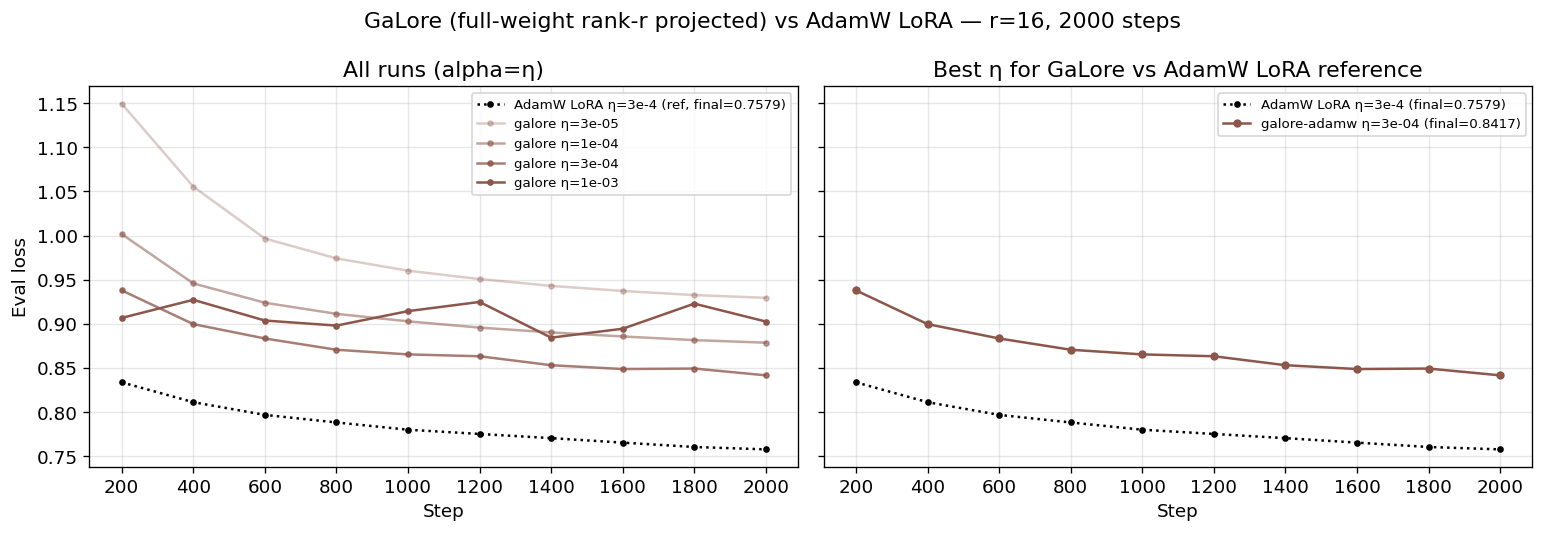

In [67]:
galore_runs = load_sweep("galore_2k") if _has_runs("galore_2k") else []
print(f"Loaded {len(galore_runs)} GaLore runs")
for cfg, evs in sorted(galore_runs, key=lambda x: x[0]["lr"]):
    print(f"  galore-adamw  η={cfg['lr']:.0e}  final={evs[-1]['eval_loss']:.4f}")

DIVERGE_THRESHOLD_GA = 1.5
ga_keep = [(c, e) for c, e in galore_runs if _max_loss(e) < DIVERGE_THRESHOLD_GA]
ga_drop = [(c, e) for c, e in galore_runs if _max_loss(e) >= DIVERGE_THRESHOLD_GA]
for cfg, evs in ga_drop:
    print(f"  [filtered] η={cfg['lr']:.0e} max={_max_loss(evs):.3f} final={evs[-1]['eval_loss']:.3f}")

# AdamW reference: best entry from the merged optim_compare runs
adamw_ref_run = None
for cfg, evs in oc_keep:
    if cfg["optimizer"] == "adamw" and abs(cfg["lr"] - 3e-4) < 1e-9:
        adamw_ref_run = (cfg, evs); break

LRS_ga = sorted({cfg["lr"] for cfg, _ in ga_keep})
lr_alphas_ga = {lr: 0.3 + 0.7 * i / max(len(LRS_ga) - 1, 1) for i, lr in enumerate(LRS_ga)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
GALORE_COLOR = "#8c564b"

# Left: all GaLore runs (alpha=η)
ax = axes[0]
if adamw_ref_run is not None:
    cfg, evs = adamw_ref_run
    ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
            color="black", lw=1.5, ls=":", marker="o", markersize=3,
            label=f"AdamW LoRA η=3e-4 (ref, final={evs[-1]['eval_loss']:.4f})")
for cfg, evs in sorted(ga_keep, key=lambda x: x[0]["lr"]):
    lr = cfg["lr"]
    steps = [e["step"] for e in evs]; losses = [e["eval_loss"] for e in evs]
    ax.plot(steps, losses, color=GALORE_COLOR, alpha=lr_alphas_ga[lr],
            marker="o", markersize=3, label=f"galore η={lr:.0e}")
ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("All runs (alpha=η)")
ax.legend(fontsize=8, loc="upper right")

# Right: best GaLore vs AdamW reference
ax = axes[1]
if adamw_ref_run is not None:
    cfg, evs = adamw_ref_run
    ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
            color="black", lw=1.5, ls=":", marker="o", markersize=3,
            label=f"AdamW LoRA η=3e-4 (final={evs[-1]['eval_loss']:.4f})")
if ga_keep:
    best = min(ga_keep, key=lambda x: x[1][-1]["eval_loss"])
    cfg, evs = best
    ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
            color=GALORE_COLOR, marker="o", markersize=4,
            label=f"galore-adamw η={cfg['lr']:.0e} (final={evs[-1]['eval_loss']:.4f})")
ax.set_xlabel("Step")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("Best η for GaLore vs AdamW LoRA reference")
ax.legend(fontsize=8)

fig.suptitle("GaLore (full-weight rank-r projected) vs AdamW LoRA — r=16, 2000 steps")
fig.tight_layout()
plt.show()